In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lsind18/gemstones-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gemstones-images' dataset.
Path to dataset files: /kaggle/input/gemstones-images


In [ ]:
import tensorflow as tf

# Check if GPU is available
gpu_available = tf.config.list_physical_devices('GPU')

if gpu_available:
    print(f"GPU is available: {gpu_available[0].name}")
    print(f"TensorFlow is built with CUDA: {tf.test.is_built_with_cuda()}")
    print("Using GPU for computations.")
else:
    print("No GPU available. TensorFlow will use CPU.")


GPU is available: /physical_device:GPU:0
TensorFlow is built with CUDA: True
Using GPU for computations.


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define base directory for the dataset
# The `path` variable is from the previous kagglehub download cell
original_data_dir = path # Keep the original downloaded path
print(f"Original downloaded path: {original_data_dir}")

# Inspect the contents of the downloaded directory
# It's common for Kaggle datasets to be extracted into a subfolder.
# For this specific dataset 'lsind18/gemstones-images', it's known to be
# nested one level deeper in a folder also named 'gemstones-images'.

first_level_contents = os.listdir(original_data_dir)
print(f"Contents of {original_data_dir}: {first_level_contents}")

# Adjust data_dir to point to the actual root of the image data
# We'll assume the dataset content is in a subfolder. A robust way is to check if it contains
# 'train', 'test' directories (and potentially 'validation')
actual_data_root = None
for item in first_level_contents:
    potential_data_path = os.path.join(original_data_dir, item)
    if os.path.isdir(potential_data_path):
        # Check if 'train' and 'test' exist directly within this subdirectory
        if all(os.path.exists(os.path.join(potential_data_path, sub_dir)) for sub_dir in ['train', 'test']):
            actual_data_root = potential_data_path
            break


if actual_data_root:
    data_dir = actual_data_root
    print(f"Detected actual data root: {data_dir}")
else:
    # Fallback or raise an error if structure is unexpected
    data_dir = original_data_dir
    print(f"Could not find a nested data root containing 'train' and 'test'. Using original path: {data_dir}")
    print("WARNING: The directory structure might be unexpected. Please verify the dataset contents.")


# Define paths for training and test sets
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

# Check if directories exist after adjustment
print(f"Checking directories:\n  Train: {train_dir} - Exists: {os.path.exists(train_dir)}\n  Test: {test_dir} - Exists: {os.path.exists(test_dir)}")


# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data Augmentation and Preprocessing for Training
# Using validation_split to create a validation set from the training data
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # 20% of training data will be used for validation
)

# Preprocessing for Test (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directories for training
train_generator = train_val_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Load images from directories for validation (from training set)
validation_generator = train_val_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Load images from directories for testing
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print(f"Number of training samples: {train_generator.samples}")
print(f"Number of validation samples: {validation_generator.samples}")
print(f"Number of test samples: {test_generator.samples}")
print(f"Number of classes: {train_generator.num_classes}")

# Get class names
class_names = list(train_generator.class_indices.keys())
print(f"Class names: {class_names}")

Original downloaded path: /kaggle/input/gemstones-images
Contents of /kaggle/input/gemstones-images: ['test', 'train']
Could not find a nested data root containing 'train' and 'test'. Using original path: /kaggle/input/gemstones-images
Checking directories:
  Train: /kaggle/input/gemstones-images/train - Exists: True
  Test: /kaggle/input/gemstones-images/test - Exists: True
Found 2313 images belonging to 87 classes.
Found 543 images belonging to 87 classes.
Found 363 images belonging to 87 classes.
Number of training samples: 2313
Number of validation samples: 543
Number of test samples: 363
Number of classes: 87
Class names: ['Alexandrite', 'Almandine', 'Amazonite', 'Amber', 'Amethyst', 'Ametrine', 'Andalusite', 'Andradite', 'Aquamarine', 'Aventurine Green', 'Aventurine Yellow', 'Benitoite', 'Beryl Golden', 'Bixbite', 'Bloodstone', 'Blue Lace Agate', 'Carnelian', 'Cats Eye', 'Chalcedony', 'Chalcedony Blue', 'Chrome Diopside', 'Chrysoberyl', 'Chrysocolla', 'Chrysoprase', 'Citrine', 'C

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load pre-trained VGG16 model without the top (classification) layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the layers of the base model to prevent them from being updated during training
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

# Combine base model and custom head into a new model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# Train the model
EPOCHS = 20 # You can adjust the number of epochs
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 87)             │        44,631 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,604,887 (105.30 MB)

 Trainable params: 12,890,199 (49.17 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 85s 942ms/step - accuracy: 0.0212 - loss: 4.5212 - val_accuracy: 0.0460 - val_loss: 4.2667
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 589ms/step - accuracy: 0.0502 - loss: 4.2258 - val_accuracy: 0.0773 - val_loss: 4.0722
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 586ms/step - accuracy: 0.0778 - loss: 4.0279 - val_accuracy: 0.1271 - val_loss: 3.8989
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 596ms/step - accuracy: 0.1224 - loss: 3.8508 - val_accuracy: 0.1989 - val_loss: 3.7078
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 588ms/step - accuracy: 0.1470 - loss: 3.6656 - val_accuracy: 0.1584 - val_loss: 3.6191
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 598ms/step - accuracy: 0.1764 - loss: 3.4949 - val_accuracy: 0.2265 - val_loss: 3.4356
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 590ms/step - accuracy: 0.1924 - loss: 3.3763 - val_accuracy: 0.2320 - val_loss: 3.2974
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 601ms/step - accuracy: 0.2464 - loss: 3.1879 - val_accu

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate the model on the test set
loss, accuracy = model.evaluate(test_generator)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Generate predictions for the test set
# Get true labels
y_true = test_generator.classes

# Get predicted probabilities
y_pred_prob = model.predict(test_generator)

# Get predicted labels (index of the highest probability)
y_pred = np.argmax(y_pred_prob, axis=1)

# Get class labels from the generator
class_labels = list(test_generator.class_indices.keys())

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(cm)


12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 992ms/step - accuracy: 0.4986 - loss: 2.0630

Test Loss: 2.0630
Test Accuracy: 0.4986
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step

Classification Report:
                   precision    recall  f1-score   support

      Alexandrite       0.00      0.00      0.00         4
        Almandine       0.00      0.00      0.00         4
        Amazonite       0.00      0.00      0.00         4
            Amber       0.00      0.00      0.00         4
         Amethyst       0.00      0.00      0.00         4
         Ametrine       0.00      0.00      0.00         4
       Andalusite       0.00      0.00      0.00         4
        Andradite       0.00      0.00      0.00         4
       Aquamarine       0.00      0.00      0.00         5
 Aventurine Green       0.00      0.00      0.00         5
Aventurine Yellow       0.00      0.00      0.00         4
        Benitoite       0.00      0.00      0.00         4
     Beryl Golden       0.00      0.00      0.00  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


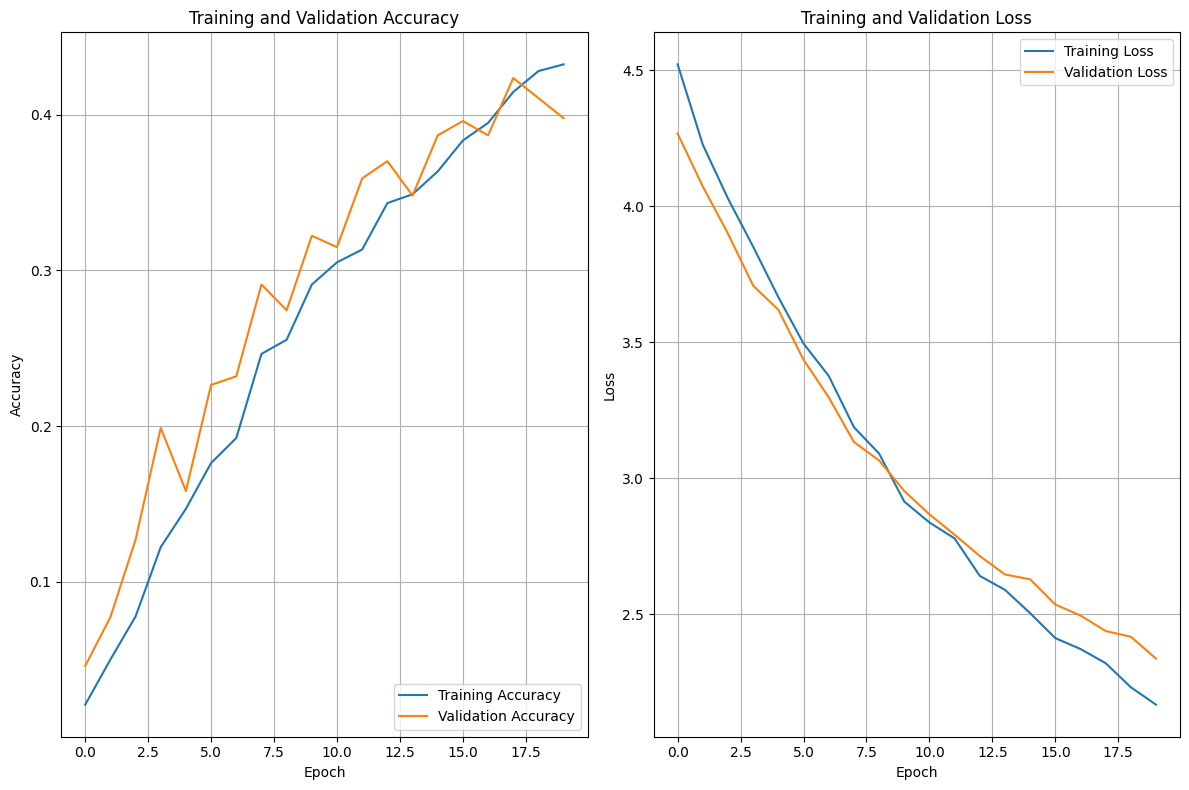

In [ ]:
import matplotlib.pyplot as plt

# Get training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 8))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()
